In [22]:
import sys
from pathlib import Path

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "viscometry").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (expected src/viscometry)")

PROJECT_ROOT = _find_repo_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

AUTO_RUNS = PROJECT_ROOT / "results" / "auto_runs"
AUTO_RUNS_LEGACY = PROJECT_ROOT / "results" / "Auto-runs"
ARCHIVE = PROJECT_ROOT / "results" / "runs" / "archive"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
auto_analyse_address = 'full_run_260428.csv'
auto_analyse_df = pd.read_csv(auto_analyse_address)

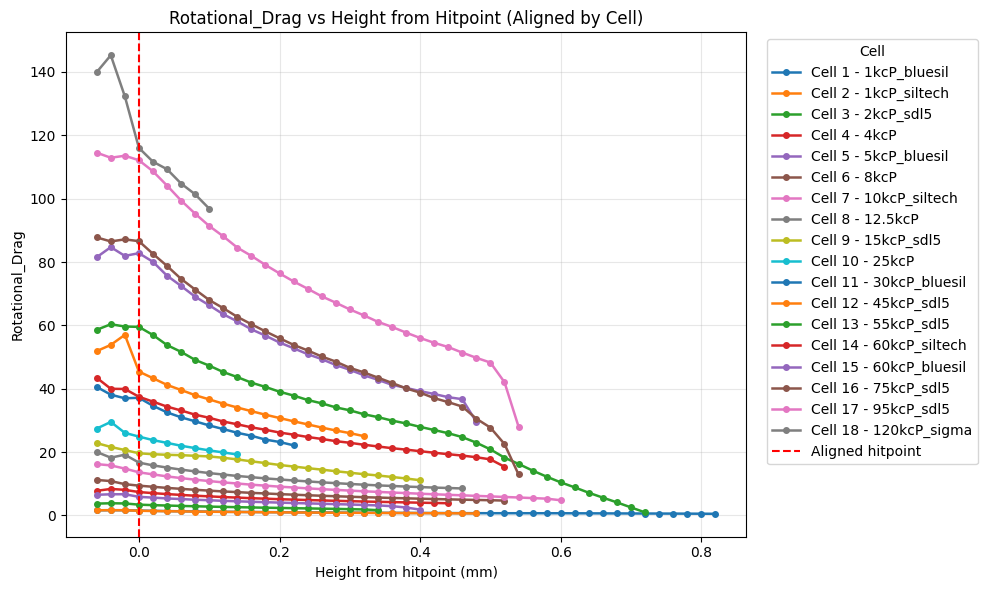

In [6]:
# Rotational_Drag vs height-from-hitpoint (one line per cell)
# Hitpoint definition per your note: the point BEFORE the last 3 points in each cell trace
plot_df = auto_analyse_df.copy()
if 'Z_Height_mm' not in plot_df.columns and 'Z_Hegiht_mm' in plot_df.columns:
    plot_df = plot_df.rename(columns={'Z_Hegiht_mm': 'Z_Height_mm'})

required_cols = {'cell', 'Z_Height_mm', 'Rotational_Drag'}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

label_col = 'Cell_Label' if 'Cell_Label' in plot_df.columns else None
cols_to_keep = ['cell', 'Z_Height_mm', 'Rotational_Drag'] + ([label_col] if label_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=['cell', 'Z_Height_mm', 'Rotational_Drag'])

plt.figure(figsize=(10, 6))
for cell_id, cell_df in plot_df.groupby('cell'):
    cell_df = cell_df.sort_values('Z_Height_mm').reset_index(drop=True)

    # Need at least 4 points so index 3 (point after first 3) exists
    if len(cell_df) < 4:
        print(f"Skipping Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    hit_idx = 3
    hit_z = cell_df.loc[hit_idx, 'Z_Height_mm']

    # Shift x-axis so hitpoint is at 0 mm
    # Assumption requested: 1 Z-height unit == 1 mm
    x_from_hit_mm = cell_df['Z_Height_mm'] - hit_z

    cell_label = ''
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    legend_label = f"Cell {int(cell_id)} - {cell_label}" if cell_label else f"Cell {int(cell_id)}"

    plt.plot(
        x_from_hit_mm,
        cell_df['Rotational_Drag'],
        marker='o',
        linewidth=1.8,
        markersize=4,
        label=legend_label
    )

# Aligned hitpoint marker (shared after shift)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Aligned hitpoint')

plt.xlabel('Height from hitpoint (mm)')
plt.ylabel('Rotational_Drag')
plt.title('Rotational_Drag vs Height from Hitpoint (Aligned by Cell)')
plt.grid(True, alpha=0.3)
plt.legend(title='Cell', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

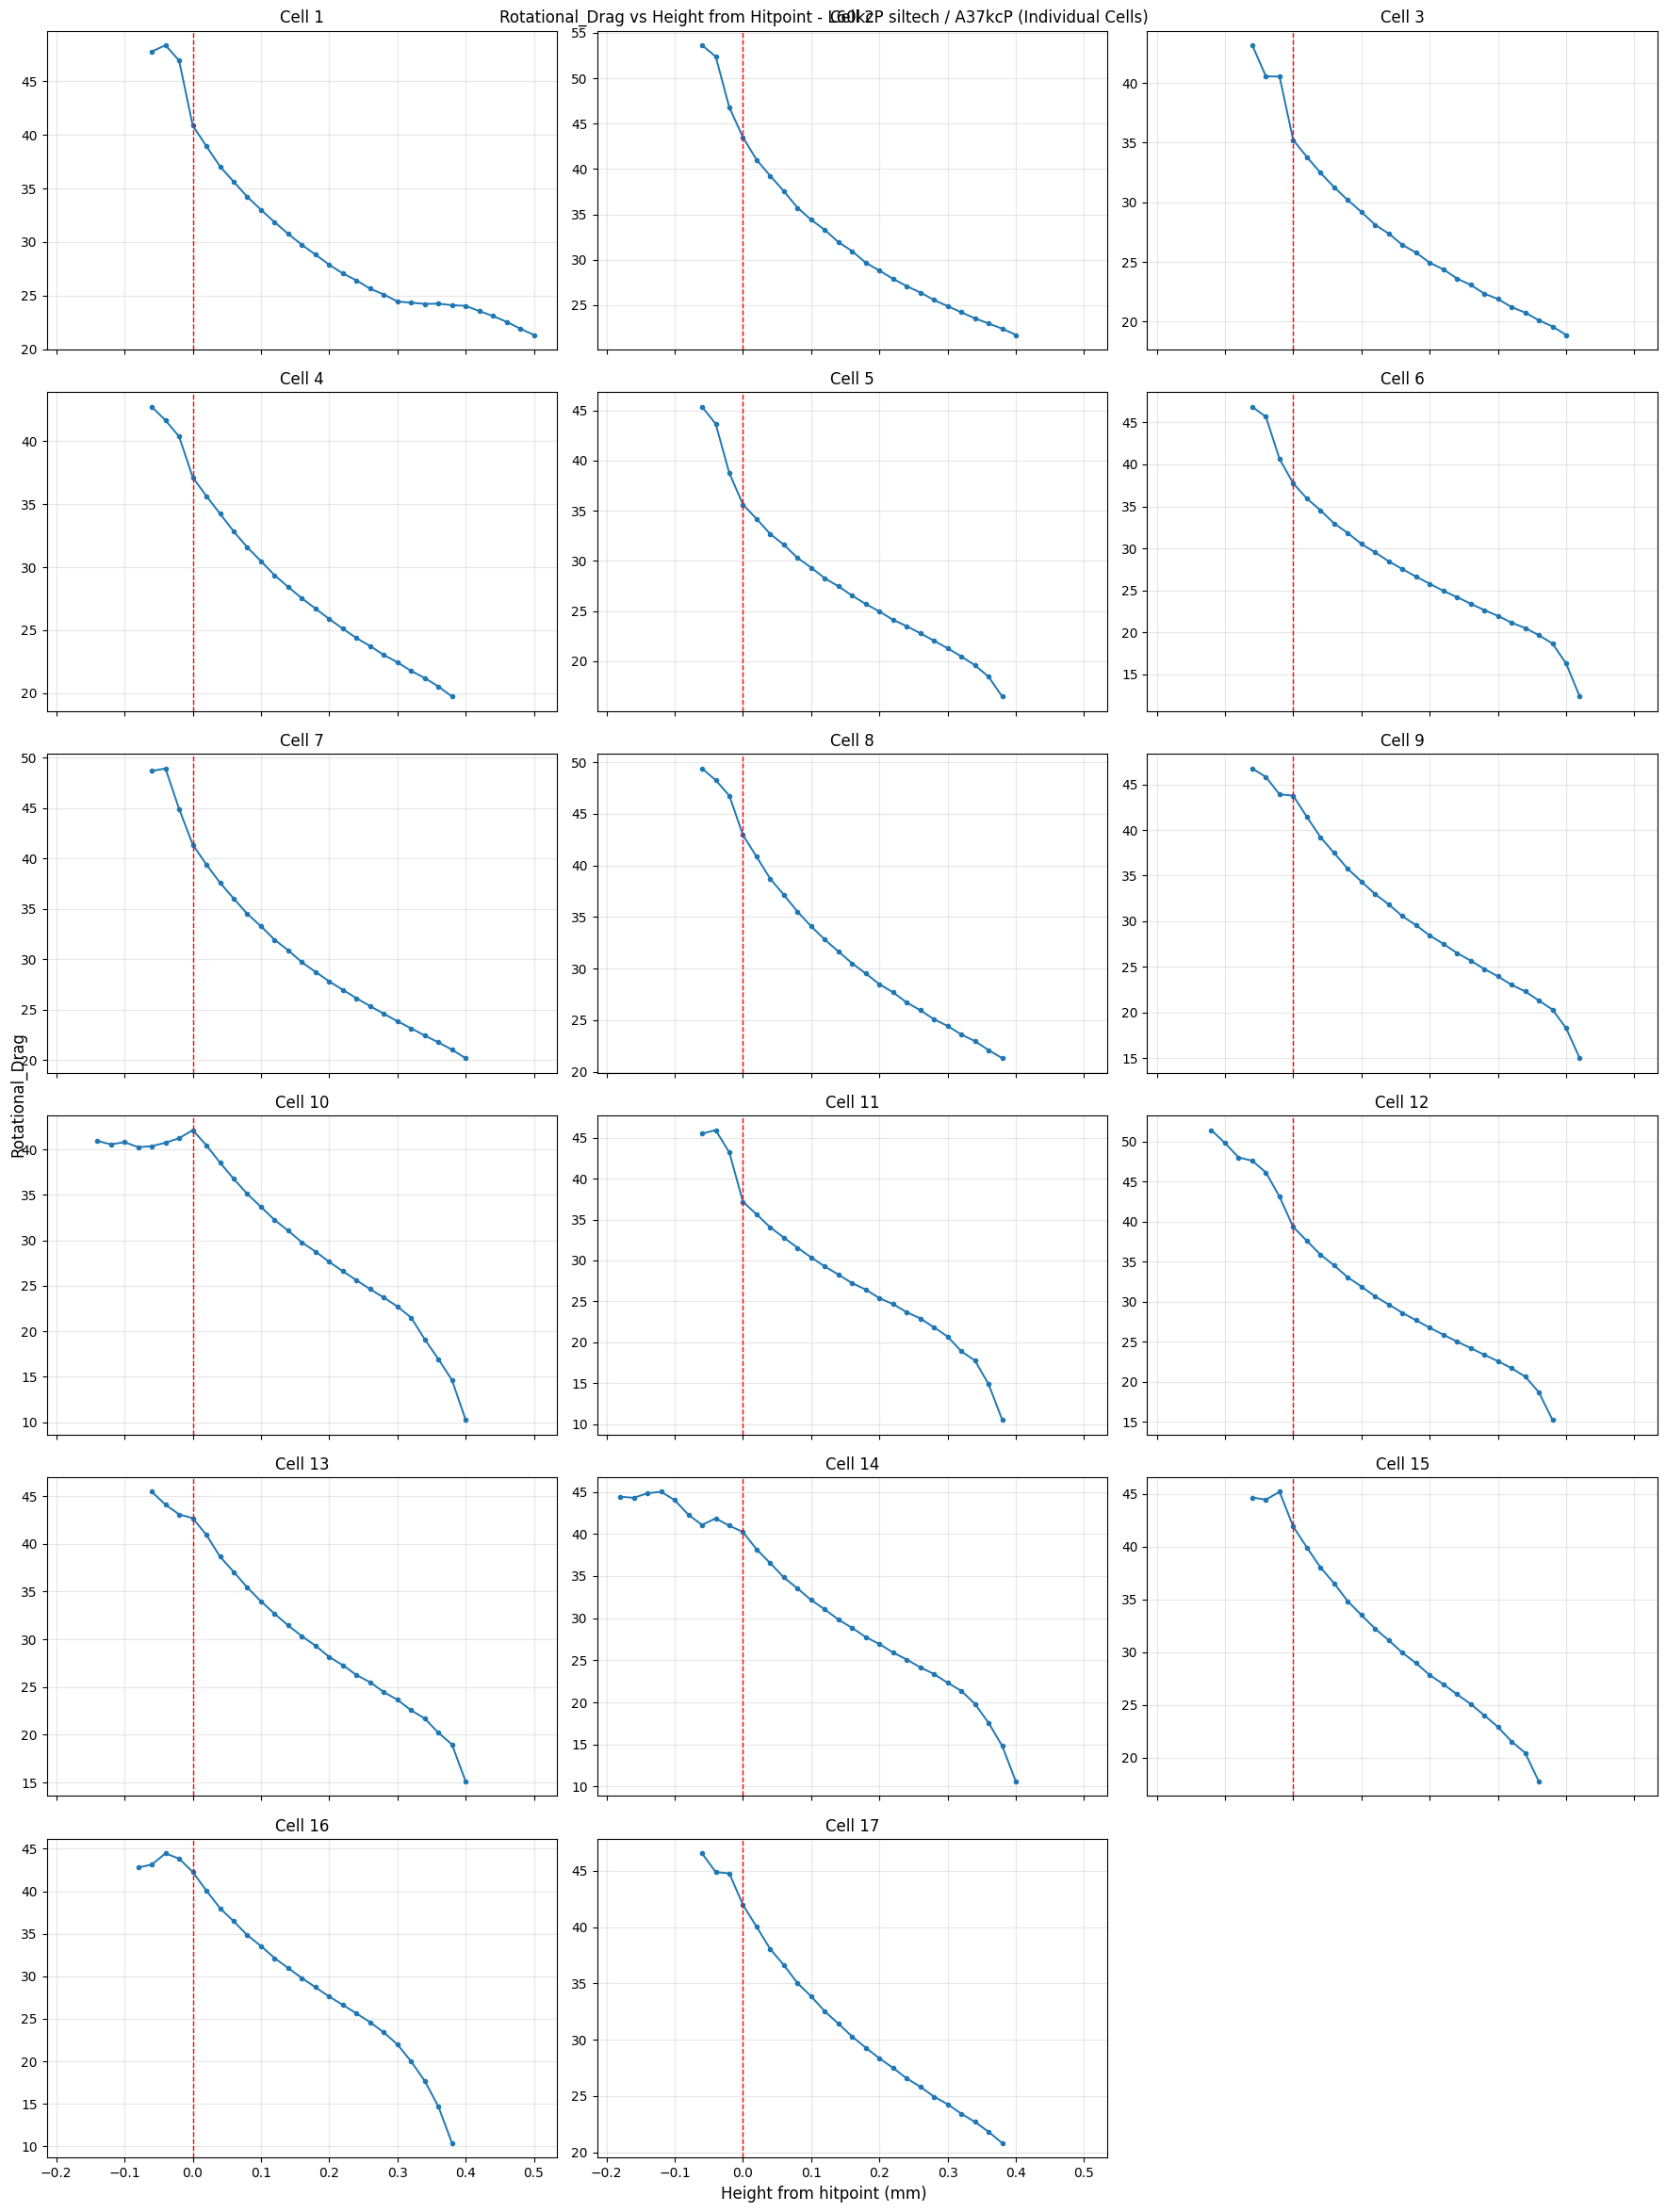

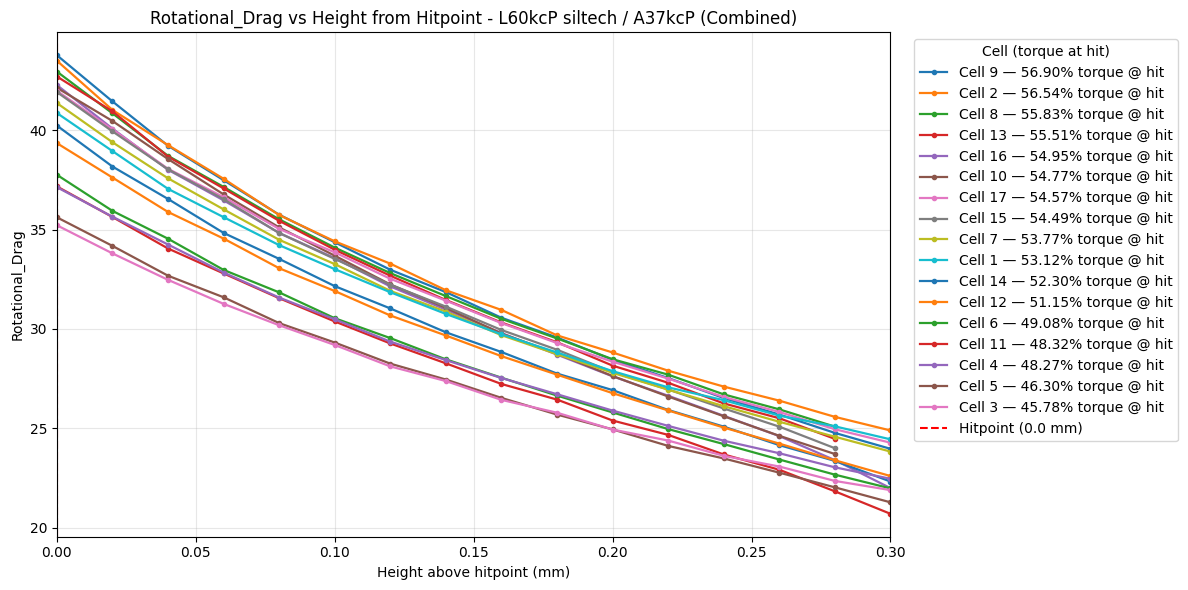

In [ ]:
# L60kcP siltech / A37kcP — same layout as cell 3 (individual grid + combined ≥ hitpoint)
# UPDATED: Now includes L10000cP data as well
dynamic_analyse_address_l60 = r"results/Auto-runs/dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv"
dynamic_analyse_df_l60 = pd.read_csv(dynamic_analyse_address_l60, encoding="cp1252", skiprows=9)

dynamic_analyse_address_l10k = r"results/auto_runs/dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv"
dynamic_analyse_df_l10k = pd.read_csv(dynamic_analyse_address_l10k, encoding="cp1252")

plot_df_dynamic_l60 = dynamic_analyse_df_l60.copy()
if "Z_Height_mm" not in plot_df_dynamic_l60.columns and "Z_Hegiht_mm" in plot_df_dynamic_l60.columns:
    plot_df_dynamic_l60 = plot_df_dynamic_l60.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

plot_df_dynamic_l10k = dynamic_analyse_df_l10k.copy()
if "Z_Height_mm" not in plot_df_dynamic_l10k.columns and "Z_Hegiht_mm" in plot_df_dynamic_l10k.columns:
    plot_df_dynamic_l10k = plot_df_dynamic_l10k.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

required_cols = {"cell", "Z_Height_mm", "Rotational_Drag"}
missing = required_cols - set(plot_df_dynamic_l60.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df_dynamic_l60.columns)}")

missing_l10k = required_cols - set(plot_df_dynamic_l10k.columns)
if missing_l10k:
    raise KeyError(f"Missing required column(s) in L10000cP: {missing_l10k}. Available: {list(plot_df_dynamic_l10k.columns)}")

label_col = "Cell_Label" if "Cell_Label" in plot_df_dynamic_l60.columns else None
torque_col = "Torque_%" if "Torque_%" in plot_df_dynamic_l60.columns else None
cols_to_keep = ["cell", "Z_Height_mm", "Rotational_Drag"] + ([label_col] if label_col else []) + ([torque_col] if torque_col else [])
plot_df_dynamic_l60 = plot_df_dynamic_l60[cols_to_keep].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

cols_to_keep_l10k = ["cell", "Z_Height_mm", "Rotational_Drag"]
plot_df_dynamic_l10k = plot_df_dynamic_l10k[cols_to_keep_l10k].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

cell_ids = sorted(plot_df_dynamic_l60["cell"].dropna().unique().tolist())
_EXCLUDED_CELLS_FOR_PLOT = {18}
cell_ids = [c for c in cell_ids if int(c) not in _EXCLUDED_CELLS_FOR_PLOT]
if not cell_ids:
    raise ValueError("No cell data available to plot.")

plot_title_base = "Rotational_Drag vs Height from Hitpoint - L60kcP siltech / A37kcP"

_COMBINED_MAX_MM_ABOVE_HIT = 0.3

_HIT_IDX_BASE = 3
_HIT_IDX_AHEAD_BY_CELL = {10: 4, 12: 3, 14: 6, 16: 1}


def _hit_idx_for_l60_cell(cell_id, n_rows):
    ahead = _HIT_IDX_AHEAD_BY_CELL.get(int(cell_id), 0)
    return min(n_rows - 1, _HIT_IDX_BASE + ahead)


n_cells = len(cell_ids)
ncols = min(3, n_cells)
nrows = int(np.ceil(n_cells / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, cell_id in zip(axes, cell_ids):
    cell_df = plot_df_dynamic_l60[plot_df_dynamic_l60["cell"] == cell_id].sort_values("Z_Height_mm").reset_index(drop=True)

    if len(cell_df) < 4:
        ax.text(0.5, 0.5, f"Skipping Cell {int(cell_id)}\nneed >=4 points", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        continue

    cell_label = ""
    if label_col:
        labels = [str(v).strip() for v in cell_df[label_col].dropna().unique() if str(v).strip()]
        if labels:
            cell_label = labels[0]

    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    hit_z = cell_df.loc[hit_idx, "Z_Height_mm"]
    x_from_hit_mm = cell_df["Z_Height_mm"] - hit_z

    ax.plot(x_from_hit_mm, cell_df["Rotational_Drag"], marker="o", linewidth=1.4, markersize=3)
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.0)
    title_suffix = f" - {cell_label}" if cell_label else ""
    ax.set_title(f"Cell {int(cell_id)}{title_suffix}")
    ax.grid(True, alpha=0.3)

for ax in axes[n_cells:]:
    ax.set_visible(False)

fig.supxlabel("Height from hitpoint (mm)")
fig.supylabel("Rotational_Drag")
fig.suptitle(f"{plot_title_base} (Individual Cells)")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))

_combined = []
for cell_id in cell_ids:
    cell_df = plot_df_dynamic_l60[plot_df_dynamic_l60["cell"] == cell_id].sort_values("Z_Height_mm").reset_index(drop=True)

    if len(cell_df) < 4:
        print(f"Skipping Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    if torque_col is not None:
        hit_torque = cell_df.loc[hit_idx, torque_col]
        t_sort = float(hit_torque) if pd.notna(hit_torque) else float("-inf")
    else:
        t_sort = float("-inf")
    _combined.append((t_sort, cell_id, cell_df, hit_idx, "L60kcP"))

# Add L10000cP data to combined plot
for cell_id in sorted(plot_df_dynamic_l10k["cell"].dropna().unique().tolist()):
    cell_df = plot_df_dynamic_l10k[plot_df_dynamic_l10k["cell"] == cell_id].sort_values("Z_Height_mm").reset_index(drop=True)

    if len(cell_df) < 4:
        print(f"Skipping L10000cP Cell {int(cell_id)}: need >=4 points to define hitpoint, found {len(cell_df)}")
        continue

    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    t_sort = float("-inf")
    _combined.append((t_sort, cell_id, cell_df, hit_idx, "L10000cP"))

_combined.sort(key=lambda x: (x[1], x[4]), reverse=False)

for t_sort, cell_id, cell_df, hit_idx, dataset_label in _combined:
    cell_label = ""
    
    hit_z = cell_df.loc[hit_idx, "Z_Height_mm"]
    x_from_hit_mm = cell_df["Z_Height_mm"] - hit_z

    plot_mask = (x_from_hit_mm >= 0.0) & (x_from_hit_mm <= _COMBINED_MAX_MM_ABOVE_HIT)
    x_plot = x_from_hit_mm[plot_mask]
    y_plot = cell_df.loc[plot_mask, "Rotational_Drag"]

    legend_label = f"Cell {int(cell_id)} ({dataset_label})"

    color = "tab:blue" if dataset_label == "L60kcP" else "tab:orange"
    marker = "o" if dataset_label == "L60kcP" else "s"
    ax.plot(x_plot, y_plot, marker=marker, linewidth=1.6, markersize=3, label=legend_label, color=color, alpha=0.7)

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="Hitpoint (0.0 mm)")

ax.set_xlim(0.0, _COMBINED_MAX_MM_ABOVE_HIT)
ax.set_xlabel("Height above hitpoint (mm)")
ax.set_ylabel("Rotational_Drag")
ax.set_title(f"Rotational_Drag vs Height (L60kcP + L10000cP Combined)")
ax.grid(True, alpha=0.3)
ax.legend(title="Dataset & Cell", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

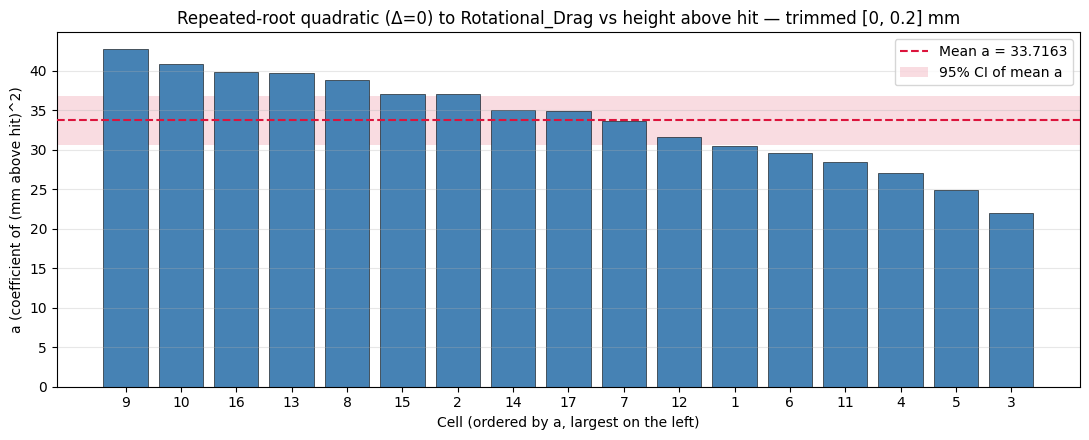

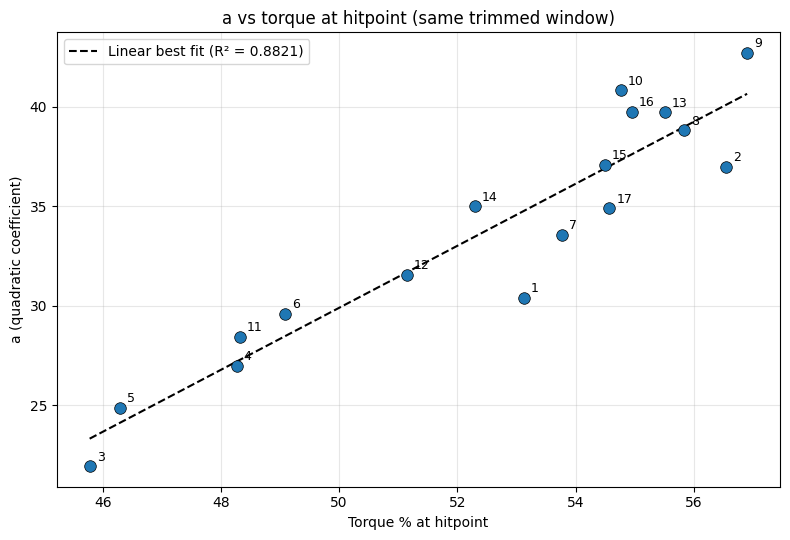

In [ ]:
# Quadratic fit with one repeated real root: y = a*x^2 + b*x + c and b^2 - 4*a*c = 0  =>  c = b^2/(4a)
# Same trimmed window as the combined L60 plot (0–0.3 mm above hit). Now includes L10000cP data.
dynamic_analyse_address_l60 = r"results/Auto-runs/dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv"
dynamic_analyse_df_l60 = pd.read_csv(dynamic_analyse_address_l60, encoding="cp1252", skiprows=9)

dynamic_analyse_address_l10k = r"results/auto_runs/dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv"
dynamic_analyse_df_l10k = pd.read_csv(dynamic_analyse_address_l10k, encoding="cp1252")

plot_df = dynamic_analyse_df_l60.copy()
if "Z_Height_mm" not in plot_df.columns and "Z_Hegiht_mm" in plot_df.columns:
    plot_df = plot_df.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

plot_df_l10k = dynamic_analyse_df_l10k.copy()
if "Z_Height_mm" not in plot_df_l10k.columns and "Z_Hegiht_mm" in plot_df_l10k.columns:
    plot_df_l10k = plot_df_l10k.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

required_cols = {"cell", "Z_Height_mm", "Rotational_Drag"}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

torque_col = "Torque_%" if "Torque_%" in plot_df.columns else None
cols_to_keep = ["cell", "Z_Height_mm", "Rotational_Drag"] + ([torque_col] if torque_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

plot_df_l10k = plot_df_l10k[["cell", "Z_Height_mm", "Rotational_Drag"]].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

_COMBINED_MAX_MM_ABOVE_HIT = 0.2
_HIT_IDX_BASE = 3
_HIT_IDX_AHEAD_BY_CELL = {10: 4, 12: 3, 14: 6, 16: 1}


def _hit_idx_for_l60_cell(cell_id, n_rows):
    ahead = _HIT_IDX_AHEAD_BY_CELL.get(int(cell_id), 0)
    return min(n_rows - 1, _HIT_IDX_BASE + ahead)


def _trimmed_xy_torque(cell_id, data_source="l60"):
    sub = plot_df[plot_df["cell"] == cell_id] if data_source == "l60" else plot_df_l10k[plot_df_l10k["cell"] == cell_id]
    if len(sub) < 4:
        return None
    cell_df = sub.sort_values("Z_Height_mm").reset_index(drop=True)
    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    hit_z = cell_df.loc[hit_idx, "Z_Height_mm"]
    x_from_hit = cell_df["Z_Height_mm"] - hit_z
    m = (x_from_hit >= 0.0) & (x_from_hit <= _COMBINED_MAX_MM_ABOVE_HIT)
    x = x_from_hit.loc[m].to_numpy(dtype=float)
    y = cell_df.loc[m, "Rotational_Drag"].to_numpy(dtype=float)
    if data_source == "l60" and torque_col is None:
        t_hit = np.nan
    else:
        t_hit = np.nan
    return x, y, t_hit


from scipy.optimize import least_squares


def _fit_quadratic_single_root(x, y):
    """Fit y ≈ a*x^2 + b*x + c with b^2 - 4*a*c = 0 (double root for a*x^2 + b*x + c = 0)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    a0, b0, _ = np.polyfit(x, y, 2)
    a_init = a0 if abs(a0) > 1e-10 else np.copysign(1e-10, a0 if a0 != 0.0 else 1.0)

    def resid(p):
        a, b = float(p[0]), float(p[1])
        c = (b * b) / (4.0 * a)
        return y - (a * x * x + b * x + c)

    sol = least_squares(
        resid,
        x0=np.array([a_init, b0], dtype=float),
        method="trf",
        loss="linear",
    )
    a, b = float(sol.x[0]), float(sol.x[1])
    if abs(a) < 1e-14:
        return float("nan"), float("nan"), float("nan")
    c = (b * b) / (4.0 * a)
    return a, b, c


rows = []
for cell_id in range(1, 18):
    pack = _trimmed_xy_torque(cell_id, "l60")
    if pack is None:
        rows.append({"cell": cell_id, "a": np.nan, "torque_at_hit": np.nan, "dataset": "L60kcP"})
        continue
    x, y, t_hit = pack
    if len(x) < 3:
        rows.append({"cell": cell_id, "a": np.nan, "torque_at_hit": t_hit, "dataset": "L60kcP"})
        continue
    a, b, c = _fit_quadratic_single_root(x, y)
    rows.append({"cell": cell_id, "a": float(a), "torque_at_hit": t_hit, "dataset": "L60kcP"})

# Add L10000cP data
for cell_id in range(1, 19):
    pack = _trimmed_xy_torque(cell_id, "l10k")
    if pack is None:
        rows.append({"cell": cell_id, "a": np.nan, "torque_at_hit": np.nan, "dataset": "L10000cP"})
        continue
    x, y, t_hit = pack
    if len(x) < 3:
        rows.append({"cell": cell_id, "a": np.nan, "torque_at_hit": t_hit, "dataset": "L10000cP"})
        continue
    a, b, c = _fit_quadratic_single_root(x, y)
    rows.append({"cell": cell_id, "a": float(a), "torque_at_hit": t_hit, "dataset": "L10000cP"})

quad_df = pd.DataFrame(rows)

# Plot histograms side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, dataset in zip([ax1, ax2], ["L60kcP", "L10000cP"]):
    coef_df = quad_df[quad_df["dataset"] == dataset].dropna(subset=["a"]).sort_values("a", ascending=True).reset_index(drop=True)
    a_vals = coef_df["a"].to_numpy(dtype=float)
    
    if len(a_vals) > 0:
        ax.hist(a_vals, bins="auto", color="steelblue", edgecolor="black", linewidth=0.4)
    ax.set_xlabel("a (coefficient of (mm above hit)^2); bins in ascending value")
    ax.set_ylabel("Number of cells")
    ax.set_title(f"Repeated-root quadratic (Δ=0) - {dataset}")
    ax.grid(True, axis="y", alpha=0.3)
    
    n_a = len(a_vals)
    if n_a >= 1:
        mean_a = float(np.mean(a_vals))
        ax.axvline(mean_a, color="crimson", linestyle="--", linewidth=1.5, zorder=5, label=f"Mean a = {mean_a:.4f}")
    if n_a >= 2:
        sem = float(np.std(a_vals, ddof=1) / np.sqrt(n_a))
        try:
            from scipy import stats as _st
            t_crit = float(_st.t.ppf(0.975, n_a - 1))
        except Exception:
            t_crit = 1.96
        ci_lo = mean_a - t_crit * sem
        ci_hi = mean_a + t_crit * sem
        ax.axvspan(ci_lo, ci_hi, facecolor="crimson", alpha=0.15, edgecolor="none", zorder=0, label="95% CI of mean a")
    if n_a >= 1:
        ax.legend(loc="best")

fig.tight_layout()
plt.show()

# Scatter plots for both datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, dataset, color in zip([ax1, ax2], ["L60kcP", "L10000cP"], ["tab:blue", "tab:orange"]):
    valid = quad_df[quad_df["dataset"] == dataset].dropna(subset=["a"])
    
    if len(valid) > 0:
        x_vals = valid["cell"].to_numpy(dtype=float)
        a_vals = valid["a"].to_numpy(dtype=float)
        ax.scatter(x_vals, a_vals, s=70, c=color, edgecolors="black", linewidths=0.5, zorder=3)
        for _, r in valid.iterrows():
            ax.annotate(str(int(r["cell"])), (r["cell"], r["a"]), textcoords="offset points", xytext=(5, 4), fontsize=9)
    
    ax.set_xlabel("Cell ID")
    ax.set_ylabel("a (quadratic coefficient)")
    ax.set_title(f"Quadratic coefficient by cell - {dataset}")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

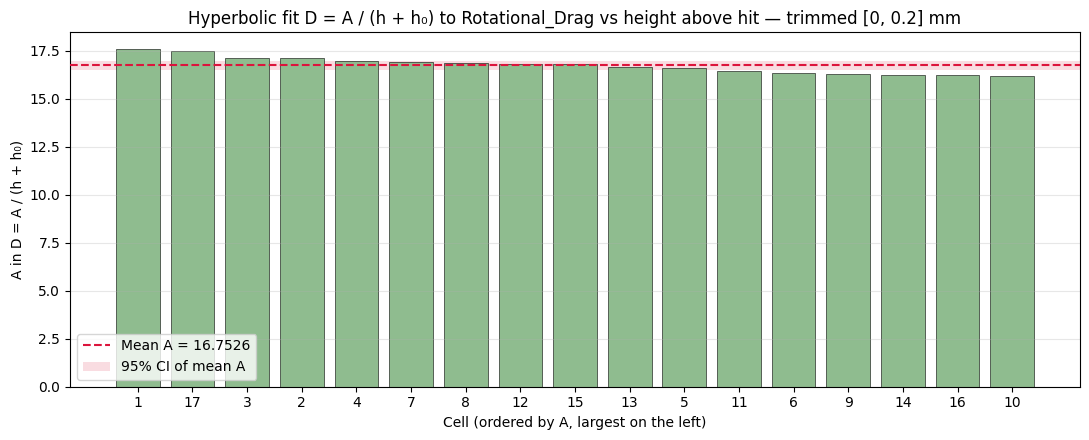

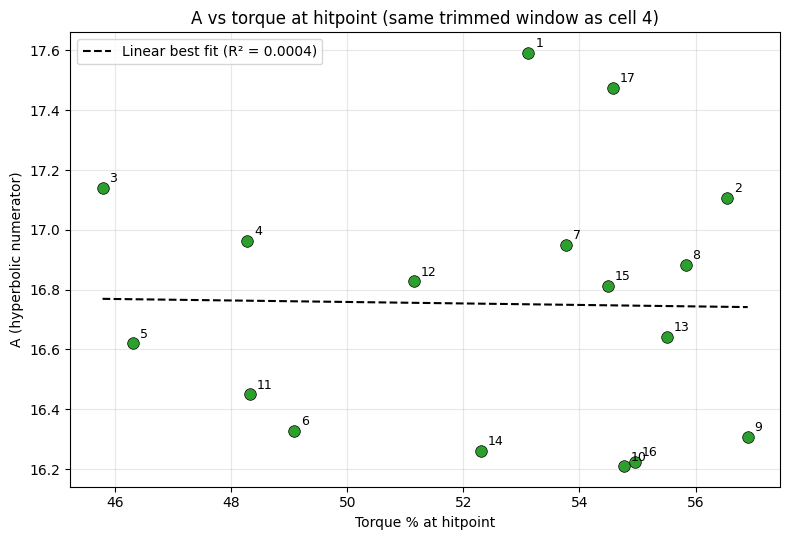

In [ ]:
# Hyperbolic fit D = A / (h + h₀) on the same trimmed window as cell 4 (Rotational_Drag vs mm above hit).
# Now includes both L60kcP and L10000cP data.

dynamic_analyse_address_l60 = r"results/Auto-runs/dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv"
dynamic_analyse_df_l60 = pd.read_csv(dynamic_analyse_address_l60, encoding="cp1252", skiprows=9)

dynamic_analyse_address_l10k = r"results/auto_runs/dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv"
dynamic_analyse_df_l10k = pd.read_csv(dynamic_analyse_address_l10k, encoding="cp1252")

plot_df = dynamic_analyse_df_l60.copy()
if "Z_Height_mm" not in plot_df.columns and "Z_Hegiht_mm" in plot_df.columns:
    plot_df = plot_df.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

plot_df_l10k = dynamic_analyse_df_l10k.copy()
if "Z_Height_mm" not in plot_df_l10k.columns and "Z_Hegiht_mm" in plot_df_l10k.columns:
    plot_df_l10k = plot_df_l10k.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

required_cols = {"cell", "Z_Height_mm", "Rotational_Drag"}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

torque_col = "Torque_%" if "Torque_%" in plot_df.columns else None
cols_to_keep = ["cell", "Z_Height_mm", "Rotational_Drag"] + ([torque_col] if torque_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

plot_df_l10k = plot_df_l10k[["cell", "Z_Height_mm", "Rotational_Drag"]].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

_COMBINED_MAX_MM_ABOVE_HIT = 0.2
_HIT_IDX_BASE = 3
_HIT_IDX_AHEAD_BY_CELL = {10: 4, 12: 3, 14: 6, 16: 1}


def _hit_idx_for_l60_cell(cell_id, n_rows):
    ahead = _HIT_IDX_AHEAD_BY_CELL.get(int(cell_id), 0)
    return min(n_rows - 1, _HIT_IDX_BASE + ahead)


def _trimmed_xy_torque(cell_id, data_source="l60"):
    sub = plot_df[plot_df["cell"] == cell_id] if data_source == "l60" else plot_df_l10k[plot_df_l10k["cell"] == cell_id]
    if len(sub) < 4:
        return None
    cell_df = sub.sort_values("Z_Height_mm").reset_index(drop=True)
    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    hit_z = cell_df.loc[hit_idx, "Z_Height_mm"]
    x_from_hit = cell_df["Z_Height_mm"] - hit_z
    m = (x_from_hit >= 0.0) & (x_from_hit <= _COMBINED_MAX_MM_ABOVE_HIT)
    x = x_from_hit.loc[m].to_numpy(dtype=float)
    y = cell_df.loc[m, "Rotational_Drag"].to_numpy(dtype=float)
    t_hit = np.nan
    return x, y, t_hit


from scipy.optimize import curve_fit


def _fit_hyperbolic_A_h0(x, y):
    """Fit y ≈ A / (x + h₀) with h₀ > 0 so (x + h₀) > 0 on the trimmed domain."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3:
        return float("nan"), float("nan")

    def model(h, A, h0):
        return A / (h + h0)

    xm = float(np.mean(x))
    ym = float(np.median(y))
    span = float(np.ptp(x)) if float(np.ptp(x)) > 1e-12 else 0.1
    h0_0 = max(1e-4, 0.1 * span)
    A_0 = ym * (xm + h0_0)
    y_scale = max(float(np.nanmax(np.abs(y))), 1e-12)
    x_max = float(np.max(x))
    h_hi = float(max(5.0, 10.0 * (x_max + 0.5)))
    A_bound = max(100.0 * y_scale * (x_max + 1.0), 1e-6)
    try:
        popt, _ = curve_fit(
            model,
            x,
            y,
            p0=[A_0, h0_0],
            bounds=([-A_bound, 1e-9], [A_bound, h_hi]),
            maxfev=50000,
        )
        A_fit, h0_fit = float(popt[0]), float(popt[1])
        if not (np.isfinite(A_fit) and np.isfinite(h0_fit)):
            return float("nan"), float("nan")
        if np.min(x + h0_fit) <= 0:
            return float("nan"), float("nan")
        return A_fit, h0_fit
    except Exception:
        return float("nan"), float("nan")


rows = []
for cell_id in range(1, 18):
    pack = _trimmed_xy_torque(cell_id, "l60")
    if pack is None:
        rows.append({"cell": cell_id, "A": np.nan, "h0": np.nan, "torque_at_hit": np.nan, "dataset": "L60kcP"})
        continue
    x, y, t_hit = pack
    if len(x) < 3:
        rows.append({"cell": cell_id, "A": np.nan, "h0": np.nan, "torque_at_hit": t_hit, "dataset": "L60kcP"})
        continue
    A_fit, h0_fit = _fit_hyperbolic_A_h0(x, y)
    rows.append({"cell": cell_id, "A": float(A_fit), "h0": float(h0_fit), "torque_at_hit": t_hit, "dataset": "L60kcP"})

# Add L10000cP data
for cell_id in range(1, 19):
    pack = _trimmed_xy_torque(cell_id, "l10k")
    if pack is None:
        rows.append({"cell": cell_id, "A": np.nan, "h0": np.nan, "torque_at_hit": np.nan, "dataset": "L10000cP"})
        continue
    x, y, t_hit = pack
    if len(x) < 3:
        rows.append({"cell": cell_id, "A": np.nan, "h0": np.nan, "torque_at_hit": t_hit, "dataset": "L10000cP"})
        continue
    A_fit, h0_fit = _fit_hyperbolic_A_h0(x, y)
    rows.append({"cell": cell_id, "A": float(A_fit), "h0": float(h0_fit), "torque_at_hit": t_hit, "dataset": "L10000cP"})

hyper_df = pd.DataFrame(rows)

# Plot histograms side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, dataset in zip([ax1, ax2], ["L60kcP", "L10000cP"]):
    coef_df = hyper_df[hyper_df["dataset"] == dataset].dropna(subset=["A"]).sort_values("A", ascending=True).reset_index(drop=True)
    A_vals = coef_df["A"].to_numpy(dtype=float)
    
    if len(A_vals) > 0:
        ax.hist(A_vals, bins="auto", color="darkseagreen", edgecolor="black", linewidth=0.4)
    ax.set_xlabel("A in D = A / (h + h₀); bins in ascending value")
    ax.set_ylabel("Number of cells")
    ax.set_title(f"Hyperbolic fit - {dataset}")
    ax.grid(True, axis="y", alpha=0.3)
    
    n_A = len(A_vals)
    if n_A >= 1:
        mean_A = float(np.mean(A_vals))
        ax.axvline(mean_A, color="crimson", linestyle="--", linewidth=1.5, zorder=5, label=f"Mean A = {mean_A:.4f}")
    if n_A >= 2:
        sem = float(np.std(A_vals, ddof=1) / np.sqrt(n_A))
        try:
            from scipy import stats as _st
            t_crit = float(_st.t.ppf(0.975, n_A - 1))
        except Exception:
            t_crit = 1.96
        ci_lo = mean_A - t_crit * sem
        ci_hi = mean_A + t_crit * sem
        ax.axvspan(ci_lo, ci_hi, facecolor="crimson", alpha=0.15, edgecolor="none", zorder=0, label="95% CI of mean A")
    if n_A >= 1:
        ax.legend(loc="best")

fig.tight_layout()
plt.show()

# Scatter plots for both datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, dataset, color in zip([ax1, ax2], ["L60kcP", "L10000cP"], ["tab:green", "tab:purple"]):
    valid = hyper_df[hyper_df["dataset"] == dataset].dropna(subset=["A"])
    
    if len(valid) > 0:
        x_vals = valid["cell"].to_numpy(dtype=float)
        A_vals = valid["A"].to_numpy(dtype=float)
        ax.scatter(x_vals, A_vals, s=70, c=color, edgecolors="black", linewidths=0.5, zorder=3)
        for _, r in valid.iterrows():
            ax.annotate(str(int(r["cell"])), (r["cell"], r["A"]), textcoords="offset points", xytext=(5, 4), fontsize=9)
    
    ax.set_xlabel("Cell ID")
    ax.set_ylabel("A (hyperbolic numerator)")
    ax.set_title(f"Hyperbolic A by cell - {dataset}")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

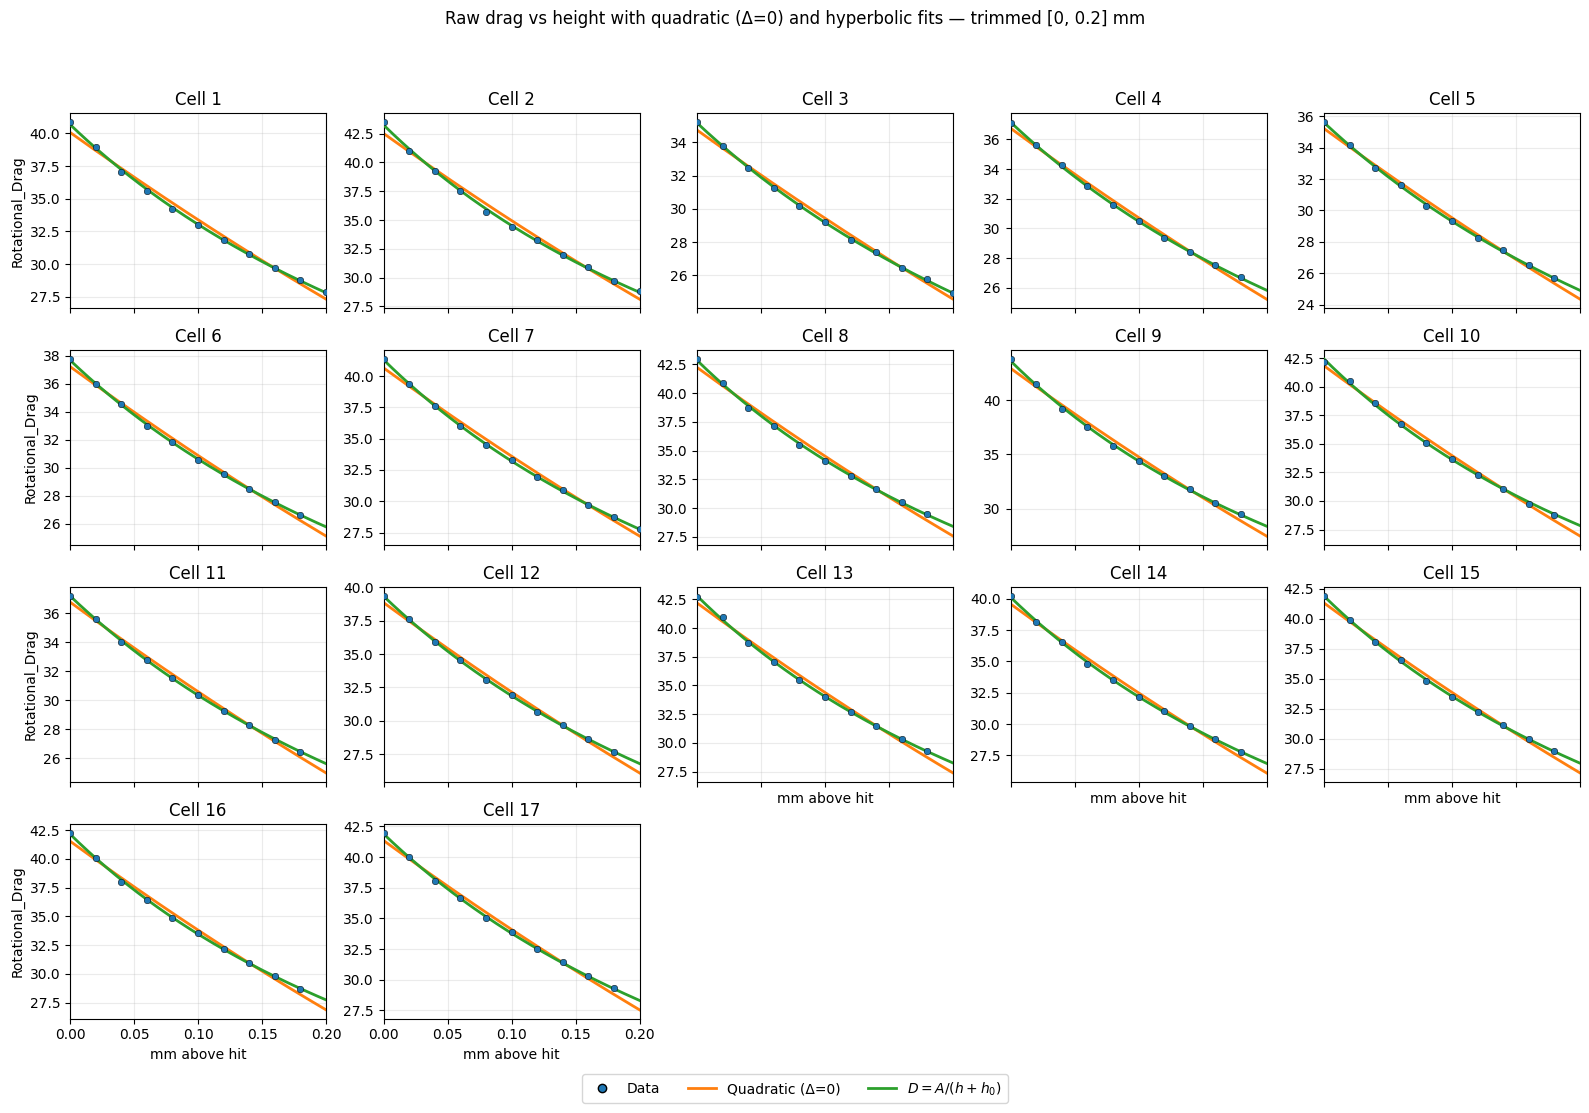

In [ ]:
# Per cell (1–17): raw Rotational_Drag vs mm above hit (same trim as cells 4–5) with overlaid
# repeated-root quadratic (Δ=0) and hyperbolic D = A/(h + h₀) model curves.
# Updated: Now includes both L60kcP and L10000cP data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dynamic_analyse_address_l60 = r"results/Auto-runs/dynamic_analysis_L60kcP_siltech_A37kcP_custom_20260511_085338.csv"
dynamic_analyse_df_l60 = pd.read_csv(dynamic_analyse_address_l60, encoding="cp1252", skiprows=9)

dynamic_analyse_address_l10k = r"results/auto_runs/dynamic_analysis_L10000cP_siltech_A11860cP_custom_20260512_090217.csv"
dynamic_analyse_df_l10k = pd.read_csv(dynamic_analyse_address_l10k, encoding="cp1252")

plot_df = dynamic_analyse_df_l60.copy()
if "Z_Height_mm" not in plot_df.columns and "Z_Hegiht_mm" in plot_df.columns:
    plot_df = plot_df.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

plot_df_l10k = dynamic_analyse_df_l10k.copy()
if "Z_Height_mm" not in plot_df_l10k.columns and "Z_Hegiht_mm" in plot_df_l10k.columns:
    plot_df_l10k = plot_df_l10k.rename(columns={"Z_Hegiht_mm": "Z_Height_mm"})

required_cols = {"cell", "Z_Height_mm", "Rotational_Drag"}
missing = required_cols - set(plot_df.columns)
if missing:
    raise KeyError(f"Missing required column(s): {missing}. Available: {list(plot_df.columns)}")

torque_col = "Torque_%" if "Torque_%" in plot_df.columns else None
cols_to_keep = ["cell", "Z_Height_mm", "Rotational_Drag"] + ([torque_col] if torque_col else [])
plot_df = plot_df[cols_to_keep].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

plot_df_l10k = plot_df_l10k[["cell", "Z_Height_mm", "Rotational_Drag"]].dropna(subset=["cell", "Z_Height_mm", "Rotational_Drag"])

_COMBINED_MAX_MM_ABOVE_HIT = 0.2
_HIT_IDX_BASE = 3
_HIT_IDX_AHEAD_BY_CELL = {10: 4, 12: 3, 14: 6, 16: 1}


def _hit_idx_for_l60_cell(cell_id, n_rows):
    ahead = _HIT_IDX_AHEAD_BY_CELL.get(int(cell_id), 0)
    return min(n_rows - 1, _HIT_IDX_BASE + ahead)


def _trimmed_xy_torque(cell_id, data_source="l60"):
    sub = plot_df[plot_df["cell"] == cell_id] if data_source == "l60" else plot_df_l10k[plot_df_l10k["cell"] == cell_id]
    if len(sub) < 4:
        return None
    cell_df = sub.sort_values("Z_Height_mm").reset_index(drop=True)
    hit_idx = _hit_idx_for_l60_cell(cell_id, len(cell_df))
    hit_z = cell_df.loc[hit_idx, "Z_Height_mm"]
    x_from_hit = cell_df["Z_Height_mm"] - hit_z
    m = (x_from_hit >= 0.0) & (x_from_hit <= _COMBINED_MAX_MM_ABOVE_HIT)
    x = x_from_hit.loc[m].to_numpy(dtype=float)
    y = cell_df.loc[m, "Rotational_Drag"].to_numpy(dtype=float)
    if data_source == "l60" and torque_col is None:
        t_hit = np.nan
    else:
        t_hit = np.nan
    return x, y, t_hit


from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, least_squares


def _fit_quadratic_single_root(x, y):
    """y ≈ a*x^2 + b*x + c with b^2 - 4*a*c = 0."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    a0, b0, _ = np.polyfit(x, y, 2)
    a_init = a0 if abs(a0) > 1e-10 else np.copysign(1e-10, a0 if a0 != 0.0 else 1.0)

    def resid(p):
        a, b = float(p[0]), float(p[1])
        c = (b * b) / (4.0 * a)
        return y - (a * x * x + b * x + c)

    sol = least_squares(
        resid,
        x0=np.array([a_init, b0], dtype=float),
        method="trf",
        loss="linear",
    )
    a, b = float(sol.x[0]), float(sol.x[1])
    if abs(a) < 1e-14:
        return float("nan"), float("nan"), float("nan")
    c = (b * b) / (4.0 * a)
    return a, b, c


def _fit_hyperbolic_A_h0(x, y):
    """y ≈ A / (x + h₀), h₀ > 0."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if len(x) < 3:
        return float("nan"), float("nan")

    def model(h, A, h0):
        return A / (h + h0)

    xm = float(np.mean(x))
    ym = float(np.median(y))
    span = float(np.ptp(x)) if float(np.ptp(x)) > 1e-12 else 0.1
    h0_0 = max(1e-4, 0.1 * span)
    A_0 = ym * (xm + h0_0)
    y_scale = max(float(np.nanmax(np.abs(y))), 1e-12)
    x_max = float(np.max(x))
    h_hi = float(max(5.0, 10.0 * (x_max + 0.5)))
    A_bound = max(100.0 * y_scale * (x_max + 1.0), 1e-6)
    try:
        popt, _ = curve_fit(
            model,
            x,
            y,
            p0=[A_0, h0_0],
            bounds=([-A_bound, 1e-9], [A_bound, h_hi]),
            maxfev=50000,
        )
        A_fit, h0_fit = float(popt[0]), float(popt[1])
        if not (np.isfinite(A_fit) and np.isfinite(h0_fit)):
            return float("nan"), float("nan")
        if np.min(x + h0_fit) <= 0:
            return float("nan"), float("nan")
        return A_fit, h0_fit
    except Exception:
        return float("nan"), float("nan")


h_fine = np.linspace(0.0, _COMBINED_MAX_MM_ABOVE_HIT, 250)

# L60kcP plots
fig, axes = plt.subplots(4, 5, figsize=(16, 11), sharex=True)
axes_flat = axes.flatten()
for k, cell_id in enumerate(range(1, 18)):
    ax = axes_flat[k]
    pack = _trimmed_xy_torque(cell_id, "l60")
    if pack is None:
        ax.set_title(f"Cell {cell_id} (no data)")
        ax.grid(True, alpha=0.25)
        continue
    x, y, _t_hit = pack
    if len(x) == 0:
        ax.set_title(f"Cell {cell_id} (empty trim)")
        ax.grid(True, alpha=0.25)
        continue
    ax.scatter(x, y, s=22, c="tab:blue", edgecolors="black", linewidths=0.35, zorder=4)
    if len(x) >= 3:
        a, b, c = _fit_quadratic_single_root(x, y)
        A_h, h0_h = _fit_hyperbolic_A_h0(x, y)
        if np.isfinite(a) and np.isfinite(b) and np.isfinite(c):
            y_q = a * h_fine**2 + b * h_fine + c
            ax.plot(h_fine, y_q, color="tab:orange", linewidth=2.0, zorder=2)
        if np.isfinite(A_h) and np.isfinite(h0_h):
            y_h = A_h / (h_fine + h0_h)
            ax.plot(h_fine, y_h, color="tab:green", linewidth=2.0, zorder=3)
    ax.set_title(f"Cell {cell_id} (L60kcP)")
    ax.set_xlim(0.0, float(_COMBINED_MAX_MM_ABOVE_HIT))
    ax.grid(True, alpha=0.25)
    if k % 5 == 0:
        ax.set_ylabel("Rotational_Drag")
    if k >= 12:
        ax.set_xlabel("mm above hit")

for j in range(17, 20):
    axes_flat[j].axis("off")

_leg = [
    Line2D([0], [0], linestyle="none", marker="o", color="tab:blue", markerfacecolor="tab:blue", markeredgecolor="black", markersize=6),
    Line2D([0], [0], color="tab:orange", linewidth=2),
    Line2D([0], [0], color="tab:green", linewidth=2),
]
fig.legend(_leg, ["Data", "Quadratic (Δ=0)", r"$D=A/(h+h_0)$"], loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.suptitle(f"L60kcP: Raw drag vs height with models — trimmed [0, {_COMBINED_MAX_MM_ABOVE_HIT}] mm", fontsize=12, y=1.01)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

# L10000cP plots
fig, axes = plt.subplots(4, 5, figsize=(16, 11), sharex=True)
axes_flat = axes.flatten()
for k, cell_id in enumerate(range(1, 19)):
    ax = axes_flat[k]
    pack = _trimmed_xy_torque(cell_id, "l10k")
    if pack is None:
        ax.set_title(f"Cell {cell_id} (no data)")
        ax.grid(True, alpha=0.25)
        continue
    x, y, _t_hit = pack
    if len(x) == 0:
        ax.set_title(f"Cell {cell_id} (empty trim)")
        ax.grid(True, alpha=0.25)
        continue
    ax.scatter(x, y, s=22, c="tab:red", edgecolors="black", linewidths=0.35, zorder=4)
    if len(x) >= 3:
        a, b, c = _fit_quadratic_single_root(x, y)
        A_h, h0_h = _fit_hyperbolic_A_h0(x, y)
        if np.isfinite(a) and np.isfinite(b) and np.isfinite(c):
            y_q = a * h_fine**2 + b * h_fine + c
            ax.plot(h_fine, y_q, color="tab:brown", linewidth=2.0, zorder=2)
        if np.isfinite(A_h) and np.isfinite(h0_h):
            y_h = A_h / (h_fine + h0_h)
            ax.plot(h_fine, y_h, color="tab:purple", linewidth=2.0, zorder=3)
    ax.set_title(f"Cell {cell_id} (L10000cP)")
    ax.set_xlim(0.0, float(_COMBINED_MAX_MM_ABOVE_HIT))
    ax.grid(True, alpha=0.25)
    if k % 5 == 0:
        ax.set_ylabel("Rotational_Drag")
    if k >= 15:
        ax.set_xlabel("mm above hit")

for j in range(18, 20):
    axes_flat[j].axis("off")

_leg = [
    Line2D([0], [0], linestyle="none", marker="o", color="tab:red", markerfacecolor="tab:red", markeredgecolor="black", markersize=6),
    Line2D([0], [0], color="tab:brown", linewidth=2),
    Line2D([0], [0], color="tab:purple", linewidth=2),
]
fig.legend(_leg, ["Data", "Quadratic (Δ=0)", r"$D=A/(h+h_0)$"], loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 0.01))
fig.suptitle(f"L10000cP: Raw drag vs height with models — trimmed [0, {_COMBINED_MAX_MM_ABOVE_HIT}] mm", fontsize=12, y=1.01)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()